# Linux Kernel Function-Call Network — Analiza sieci złożonej

Graf wywołań funkcji jądra Linux skompilowanego z `allmodconfig`.  
Węzły = funkcje, krawędzie = wywołania (skierowane).

**Pipeline:**  
1. Podstawowe statystyki i rozkład stopni  
2. Identyfikacja hubów (PageRank, in-degree)  
3. Analiza subsystemów — sprzężenia i samowystarczalność  
4. Macierz zależności między subsystemami  
5. Detekcja społeczności (Louvain) i porównanie z subsystemami  
6. Dekompozycja k-core — "jądro jądra"  
7. Wnioski

In [ ]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

try:
    import networkit as nk

    HAS_NK = True
except ImportError:
    HAS_NK = False
    print("NetworKit nie jest zainstalowany — niektóre sekcje będą pominięte")

DATA = Path("../data/out")
LINUX = Path("../data/linux")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
sns.set_palette("tab10")
print("Gotowe.")

Gotowe.


## 1. Wczytanie danych i podstawowe statystyki

In [ ]:
metrics = pd.read_csv(DATA / "node_metrics.csv")
subsys = pd.read_csv(DATA / "subsystem_stats.csv")
hubs = pd.read_csv(DATA / "top_hubs.csv")

N = len(metrics)
E = int(metrics["out_degree"].sum())  # suma out-degree = liczba krawędzi

density = E / (N * (N - 1))
avg_in = metrics["in_degree"].mean()
avg_out = metrics["out_degree"].mean()
max_in = metrics["in_degree"].max()
max_out = metrics["out_degree"].max()
pct_zero_in = (metrics["in_degree"] == 0).mean() * 100
pct_zero_out = (metrics["out_degree"] == 0).mean() * 100

print(f"Węzły (funkcje):          {N:>10,}")
print(f"Krawędzie (wywołania):    {E:>10,}")
print(f"Gęstość grafu:            {density:.2e}")
print(f"Średni in-degree:         {avg_in:>10.2f}")
print(f"Średni out-degree:        {avg_out:>10.2f}")
print(f"Max in-degree:            {int(max_in):>10,}")
print(f"Max out-degree:           {int(max_out):>10,}")
print(f"Funkcje bez wywołującego: {pct_zero_in:>9.1f}%")
print(f"Funkcje bez wywołań:      {pct_zero_out:>9.1f}%")
print(f"Liczba subsystemów:       {len(subsys):>10,}")

Węzły (funkcje):             466,572
Krawędzie (wywołania):     4,440,158
Gęstość grafu:            2.04e-05
Średni in-degree:               9.52
Średni out-degree:              9.52
Max in-degree:               426,077
Max out-degree:                  330
Funkcje bez wywołującego:      43.9%
Funkcje bez wywołań:            3.9%
Liczba subsystemów:              150


## 2. Rozkład stopni — czy sieć jest bezskalowa?

Sieci rzeczywiste (internet, sieci społecznościowe, sieci biologiczne) często mają rozkład potęgowy stopni: $P(k) \sim k^{-\gamma}$.  
W skali log-log daje to prostą linię. Sprawdzimy, czy tak jest tutaj.

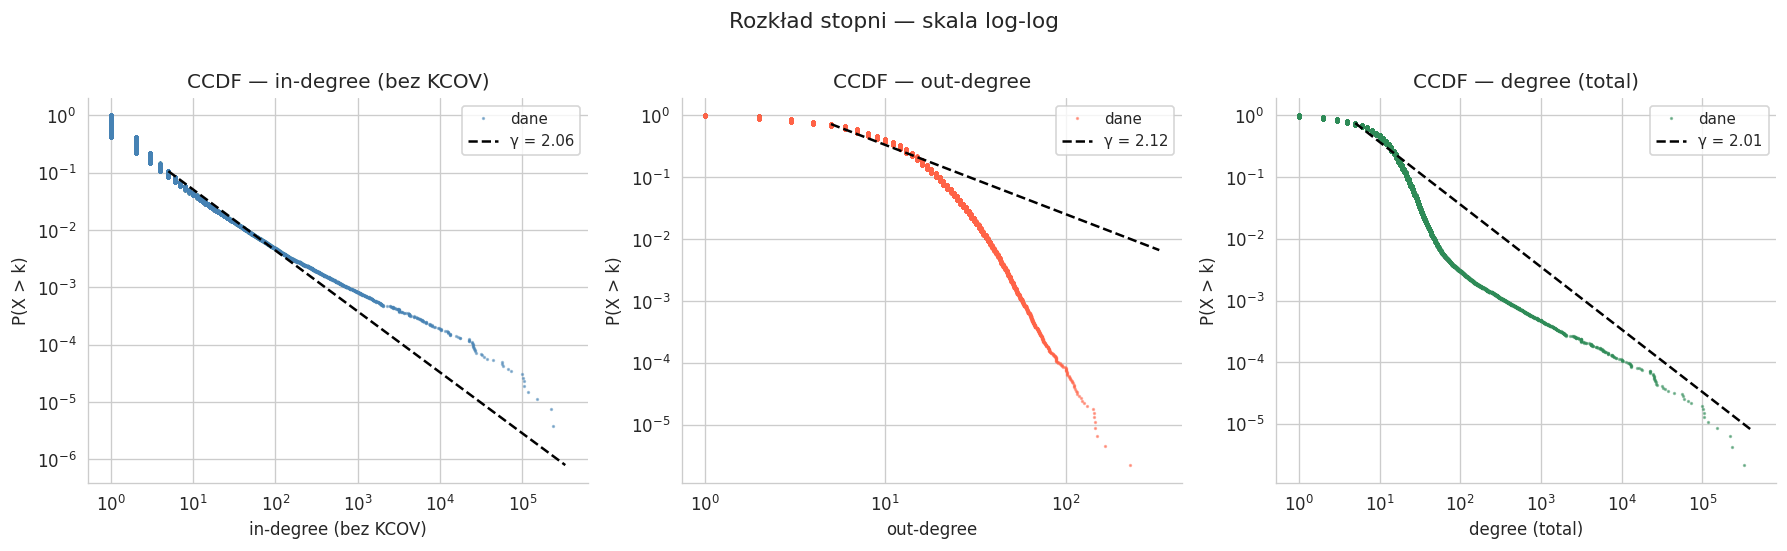

Wykres zapisany.


In [ ]:
def ccdf(values):
    """Complementary CDF — P(X > k)."""
    sorted_v = np.sort(values)
    p = 1.0 - np.arange(1, len(sorted_v) + 1) / len(sorted_v)
    return sorted_v, p


def powerlaw_fit(values, k_min=5):
    """MLE dla wykładnika rozkładu potęgowego (Clauset et al.)."""
    v = values[values >= k_min]
    n = len(v)
    gamma = 1 + n / np.sum(np.log(v / (k_min - 0.5)))
    return gamma, k_min, n


in_deg = metrics["in_degree"].values.astype(float)
out_deg = metrics["out_degree"].values.astype(float)

kcov_mask = metrics["func_name"] == "__sanitizer_cov_trace_pc"
in_deg_clean = metrics.loc[~kcov_mask, "in_degree"].values.astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, deg, label, color in [
    (axes[0], in_deg_clean, "in-degree (bez KCOV)", "steelblue"),
    (axes[1], out_deg[out_deg > 0], "out-degree", "tomato"),
    (axes[2], metrics["degree"].values, "degree (total)", "seagreen"),
]:
    deg = deg[deg > 0]
    x, p = ccdf(deg)
    ax.loglog(x, p, ".", markersize=2, alpha=0.5, color=color, label="dane")

    gamma, kmin, n_fit = powerlaw_fit(deg)
    x_fit = np.logspace(np.log10(kmin), np.log10(deg.max()), 200)
    C = p[np.searchsorted(x, kmin)]
    y_fit = C * (x_fit / kmin) ** (-(gamma - 1))
    ax.loglog(x_fit, y_fit, "--", color="black", lw=1.5, label=f"γ = {gamma:.2f}")

    ax.set_xlabel(label)
    ax.set_ylabel("P(X > k)")
    ax.set_title(f"CCDF — {label}")
    ax.legend(fontsize=9)

plt.suptitle("Rozkład stopni — skala log-log", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA / "degree_distribution.png", bbox_inches="tight")
plt.show()
print("Wykres zapisany.")

## 3. Huby — najważniejsze funkcje w sieci

PageRank i in-degree wskazują na różne typy centralności:
- **in-degree**: funkcje najczęściej *wywoływane* — interfejsy niskiego poziomu
- **PageRank**: funkcje ważne *globalnie* — wywoływane przez inne ważne funkcje

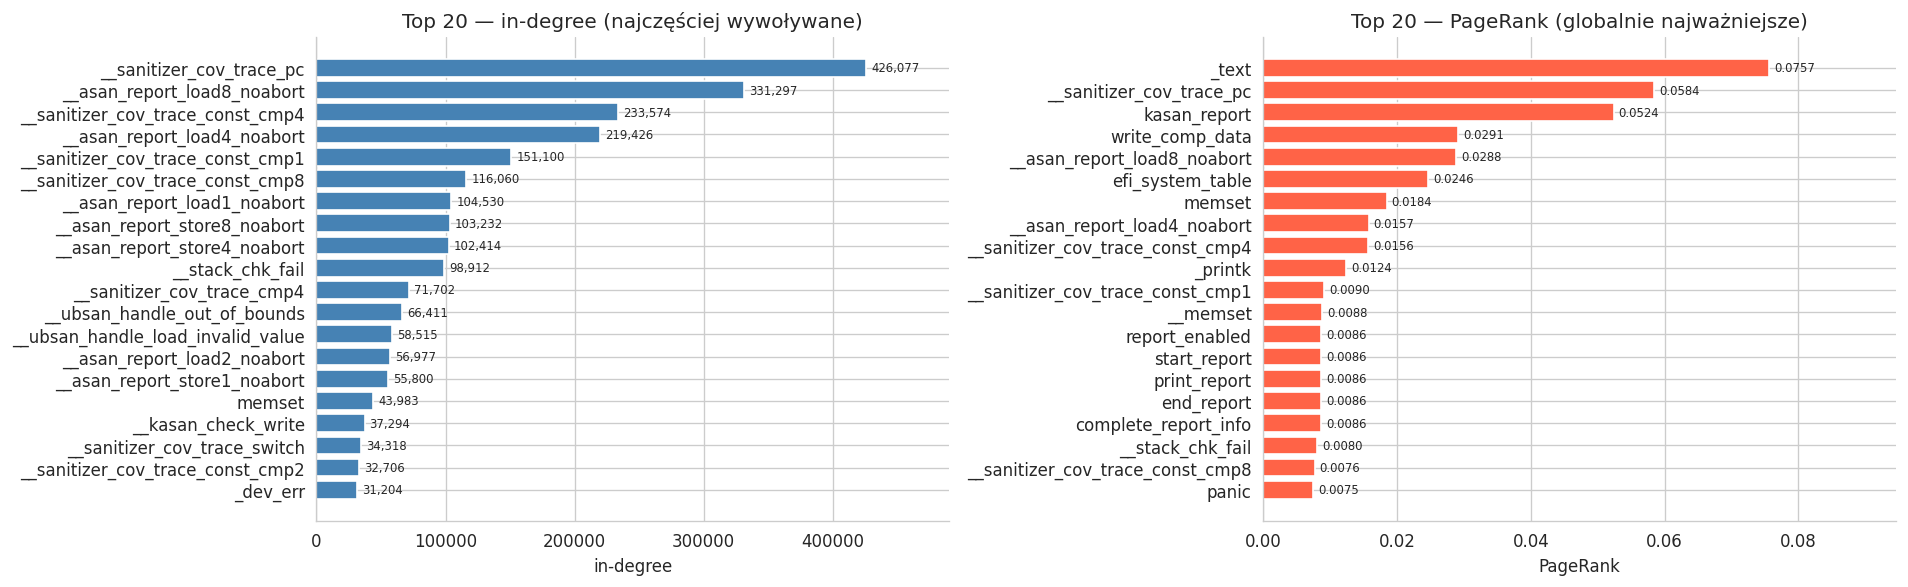


Top 10 in-degree:
                       func_name subsystem  in_degree  pagerank
        __sanitizer_cov_trace_pc    kernel   426077.0  0.058400
     __asan_report_load8_noabort        mm   331297.0  0.028833
__sanitizer_cov_trace_const_cmp4    kernel   233574.0  0.015619
     __asan_report_load4_noabort        mm   219426.0  0.015743
__sanitizer_cov_trace_const_cmp1    kernel   151100.0  0.009044
__sanitizer_cov_trace_const_cmp8    kernel   116060.0  0.007645
     __asan_report_load1_noabort        mm   104530.0  0.006115
    __asan_report_store8_noabort        mm   103232.0  0.006564
    __asan_report_store4_noabort        mm   102414.0  0.006677
                __stack_chk_fail  external    98912.0  0.007992

Top 10 PageRank:
                       func_name        subsystem  in_degree  pagerank
                           _text         external       29.0  0.075692
        __sanitizer_cov_trace_pc           kernel   426077.0  0.058400
                    kasan_report              

In [ ]:
top20_in = metrics.nlargest(20, "in_degree")[
    ["func_name", "subsystem", "in_degree", "pagerank"]
].reset_index(drop=True)
top20_pr = metrics.nlargest(20, "pagerank")[
    ["func_name", "subsystem", "in_degree", "pagerank"]
].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
df = top20_in.iloc[::-1]
bars = ax.barh(df["func_name"], df["in_degree"], color="steelblue")
ax.set_xlabel("in-degree")
ax.set_title("Top 20 — in-degree (najczęściej wywoływane)")
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=7)
ax.set_xlim(0, df["in_degree"].max() * 1.15)

ax = axes[1]
df = top20_pr.iloc[::-1]
bars = ax.barh(df["func_name"], df["pagerank"], color="tomato")
ax.set_xlabel("PageRank")
ax.set_title("Top 20 — PageRank (globalnie najważniejsze)")
ax.bar_label(bars, fmt="{:.4f}", padding=3, fontsize=7)
ax.set_xlim(0, df["pagerank"].max() * 1.25)

plt.tight_layout()
plt.savefig(DATA / "top_hubs.png", bbox_inches="tight")
plt.show()

print("\nTop 10 in-degree:")
print(top20_in.head(10).to_string(index=False))
print("\nTop 10 PageRank:")
print(top20_pr.head(10).to_string(index=False))

## 4. Analiza subsystemów

### 4a. Wielkość i aktywność subsystemów

Subsystemów z ≥100 węzłów: 128
Pokrycie węzłów: 99.8%


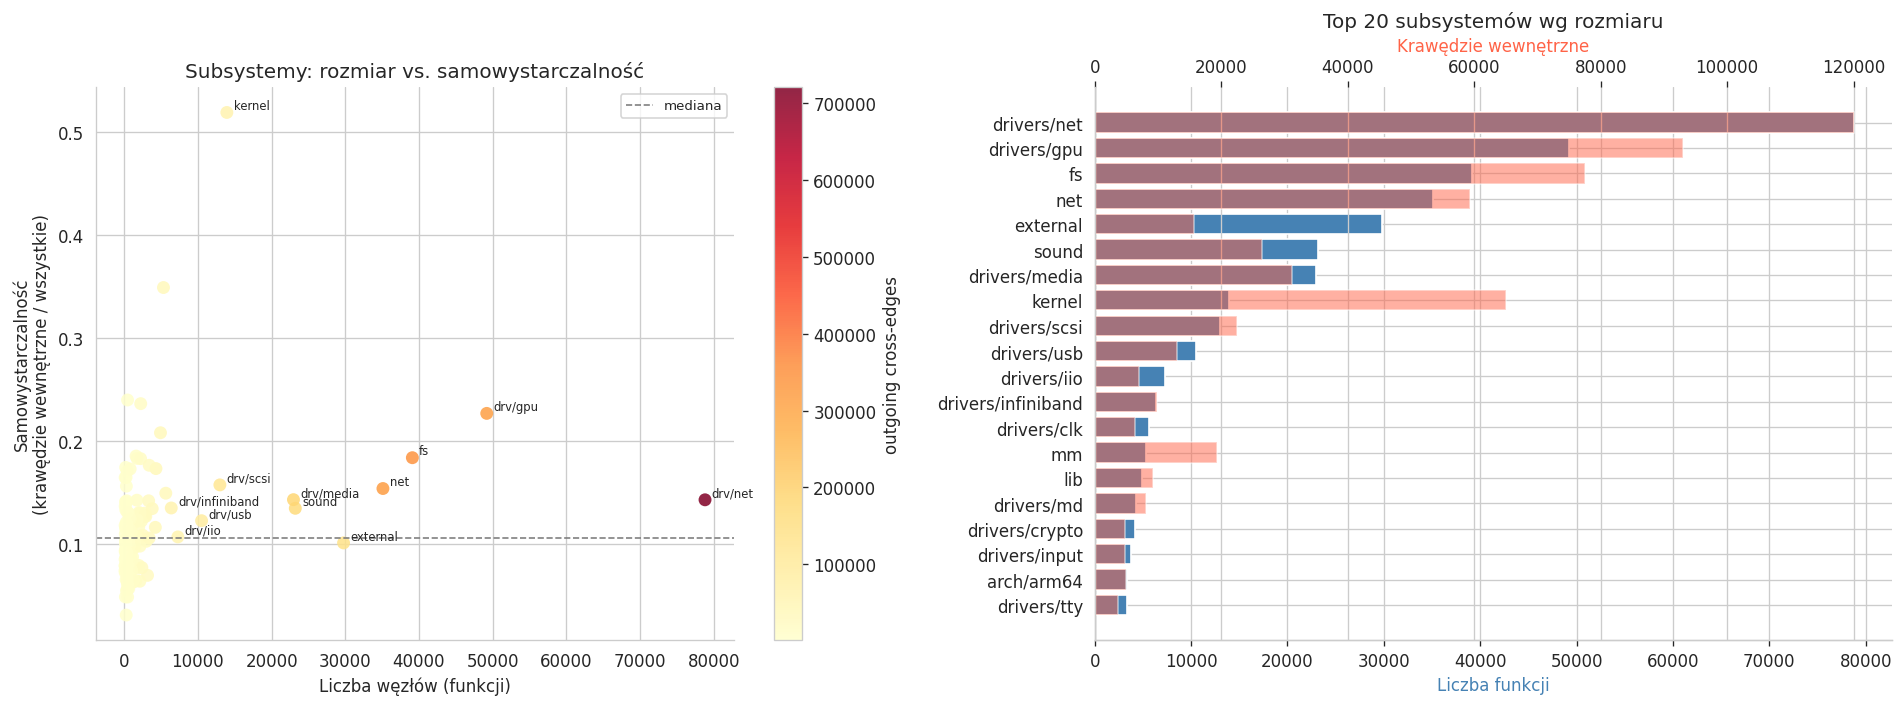

In [ ]:
subsys["total_edges"] = subsys["internal_edges"] + subsys["outgoing_cross_edges"]
subsys["self_containment"] = subsys["internal_edges"] / subsys["total_edges"].replace(
    0, np.nan
)

THRESHOLD = 100
top_sys = subsys[subsys["nodes"] >= THRESHOLD].sort_values("nodes", ascending=False)
print(f"Subsystemów z ≥{THRESHOLD} węzłów: {len(top_sys)}")
print(f"Pokrycie węzłów: {top_sys['nodes'].sum() / subsys['nodes'].sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sc = ax.scatter(
    top_sys["nodes"],
    top_sys["self_containment"],
    c=top_sys["outgoing_cross_edges"],
    cmap="YlOrRd",
    s=60,
    edgecolors="none",
    alpha=0.85,
)
plt.colorbar(sc, ax=ax, label="outgoing cross-edges")
for _, row in top_sys.nlargest(12, "nodes").iterrows():
    ax.annotate(
        row["subsystem"].replace("drivers/", "drv/"),
        (row["nodes"], row["self_containment"]),
        fontsize=7,
        xytext=(4, 2),
        textcoords="offset points",
    )
ax.set_xlabel("Liczba węzłów (funkcji)")
ax.set_ylabel("Samowystarczalność\n(krawędzie wewnętrzne / wszystkie)")
ax.set_title("Subsystemy: rozmiar vs. samowystarczalność")
ax.axhline(
    top_sys["self_containment"].median(), color="gray", ls="--", lw=1, label="mediana"
)
ax.legend(fontsize=8)

ax = axes[1]
df20 = top_sys.nlargest(20, "nodes").iloc[::-1]
ax.barh(df20["subsystem"], df20["nodes"], color="steelblue", label="węzły")
ax2 = ax.twiny()
ax2.barh(
    df20["subsystem"],
    df20["internal_edges"],
    color="tomato",
    alpha=0.5,
    label="krawędzie wewn.",
)
ax.set_xlabel("Liczba funkcji", color="steelblue")
ax2.set_xlabel("Krawędzie wewnętrzne", color="tomato")
ax.set_title("Top 20 subsystemów wg rozmiaru")

plt.tight_layout()
plt.savefig(DATA / "subsystem_overview.png", bbox_inches="tight")
plt.show()

### 4b. Macierz zależności między subsystemami (cross-call heatmap)

Który subsystem jest "źródłem" największej liczby wywołań do innych?  
Budujemy agregowaną macierz na poziomie subsystemów.

Wczytuję krawędzie — może chwilę potrwać (~4.4M wierszy)...
Krawędzi: 4,440,158


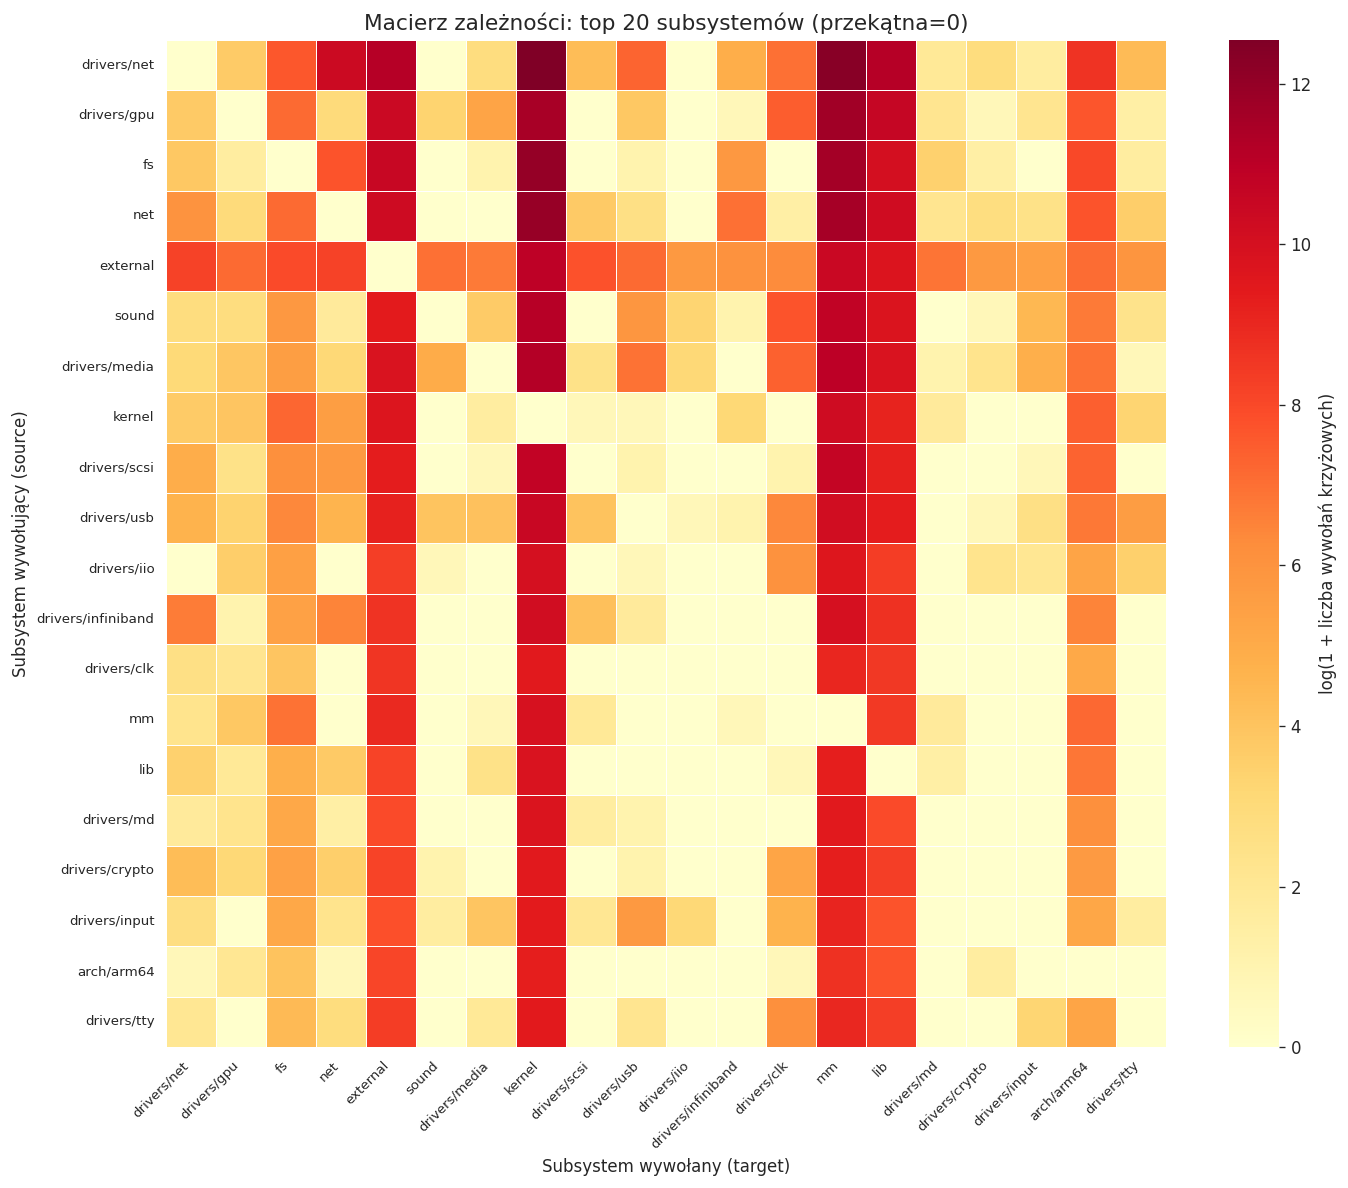


Najsilniejsze zależności krzyżowe (top 15):
   source_sys target_sys  calls
  drivers/net     kernel 281636
  drivers/net         mm 223006
           fs     kernel 160076
          net     kernel 151214
  drivers/gpu         mm 117311
           fs         mm 108265
          net         mm 105378
  drivers/gpu     kernel  98952
drivers/media     kernel  74613
  drivers/net        lib  70888
  drivers/net   external  68905
        sound     kernel  66597
drivers/media         mm  57689
     external     kernel  53258
        sound         mm  50524


In [ ]:
print("Wczytuję krawędzie — może chwilę potrwać (~4.4M wierszy)...")
edges = pd.read_csv(DATA / "edges.csv")
print(f"Krawędzi: {len(edges):,}")

node_sub = metrics[["id", "subsystem"]].set_index("id")
edges = edges.join(node_sub.rename(columns={"subsystem": "src_sys"}), on="source")
edges = edges.join(node_sub.rename(columns={"subsystem": "tgt_sys"}), on="target")
edges = edges.dropna(subset=["src_sys", "tgt_sys"])

TOP_N = 20
top_names = subsys.nlargest(TOP_N, "nodes")["subsystem"].tolist()

cross = (
    edges[edges["src_sys"].isin(top_names) & edges["tgt_sys"].isin(top_names)]
    .groupby(["src_sys", "tgt_sys"])
    .size()
    .unstack(fill_value=0)
)
cross = cross.reindex(index=top_names, columns=top_names, fill_value=0)

cross = cross.where(~np.eye(len(cross), dtype=bool), 0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    np.log1p(cross),
    ax=ax,
    cmap="YlOrRd",
    xticklabels=cross.columns,
    yticklabels=cross.index,
    linewidths=0.3,
    cbar_kws={"label": "log(1 + liczba wywołań krzyżowych)"},
)
ax.set_title(f"Macierz zależności: top {TOP_N} subsystemów (przekątna=0)", fontsize=13)
ax.set_xlabel("Subsystem wywołany (target)")
ax.set_ylabel("Subsystem wywołujący (source)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(DATA / "cross_subsystem_heatmap.png", bbox_inches="tight")
plt.show()

print("\nNajsilniejsze zależności krzyżowe (top 15):")
cross_flat = cross.stack().reset_index()
cross_flat.columns = ["source_sys", "target_sys", "calls"]
print(
    cross_flat[cross_flat["source_sys"] != cross_flat["target_sys"]]
    .nlargest(15, "calls")
    .to_string(index=False)
)

## 5. Detekcja społeczności (Louvain) vs subsystemy

Używamy algorytmu Louvain (z NetworKit) — szybkiego algorytmu detekcji społeczności.  
Pytanie: **czy algorytm "odgadnie" strukturę subsystemów bez wiedzy o kodzie?**

Jako miarę jakości użyjemy **NMI** (Normalized Mutual Information) — 0 = losowe, 1 = idealne odwzorowanie.

In [ ]:
if not HAS_NK:
    print("NetworKit nie jest zainstalowany — instaluję...")
    import subprocess, sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "networkit", "-q"])
    import networkit as nk

    HAS_NK = True

from sklearn.metrics import normalized_mutual_info_score

print("Buduję mapowanie węzłów...")
all_nodes = metrics["id"].tolist()
node2id = {n: i for i, n in enumerate(all_nodes)}
n_nodes = len(all_nodes)

print(f"Buduję graf NetworKit ({n_nodes:,} węzłów)...")
G = nk.Graph(n_nodes, weighted=False, directed=False)

added = 0
for src, tgt in zip(edges["source"], edges["target"]):
    u = node2id.get(src)
    v = node2id.get(tgt)
    if u is not None and v is not None and u != v:
        if not G.hasEdge(u, v):
            G.addEdge(u, v)
            added += 1

print(f"Krawędzi w grafie: {G.numberOfEdges():,}")

print("Uruchamiam Louvain...")
louvain = nk.community.PLM(G, refine=False, gamma=1.0)
louvain.run()
partition = louvain.getPartition()
print(f"Louvain znalazł {partition.numberOfSubsets()} społeczności")
print(f"Modularność: {nk.community.Modularity().getQuality(partition, G):.4f}")

Buduję mapowanie węzłów...
Buduję graf NetworKit (466,572 węzłów)...
Krawędzi w grafie: 4,439,715
Uruchamiam Louvain...
Louvain znalazł 989 społeczności
Modularność: 0.3123


NMI (Louvain vs subsystemy): 0.1148
(0 = losowe, 1 = idealne odwzorowanie)

Czystość społeczności (jaki % węzłów pochodzi z dominującego subsystemu):
count    989.000000
mean       0.970503
std        0.095592
min        0.131703
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: subsystem, dtype: float64


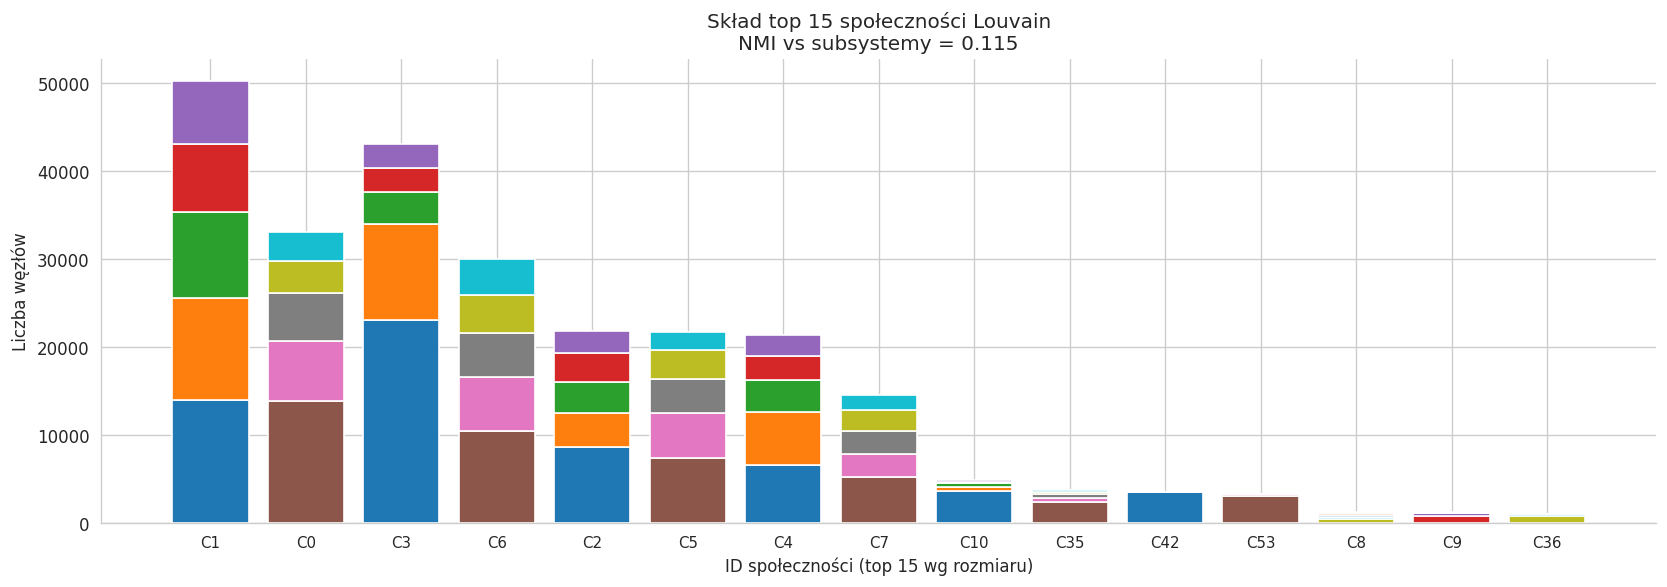

In [ ]:
from sklearn.preprocessing import LabelEncoder

community_labels = np.array([partition.subsetOf(i) for i in range(n_nodes)])

subsystem_labels_raw = metrics["subsystem"].fillna("unknown").values
le = LabelEncoder()
subsystem_labels = le.fit_transform(subsystem_labels_raw)

nmi = normalized_mutual_info_score(subsystem_labels, community_labels)
print(f"NMI (Louvain vs subsystemy): {nmi:.4f}")
print("(0 = losowe, 1 = idealne odwzorowanie)")

metrics["community"] = community_labels
overlap = (
    metrics.groupby("community")["subsystem"]
    .agg(lambda x: x.value_counts().iloc[0] / len(x))
    .describe()
)
print("\nCzystość społeczności (jaki % węzłów pochodzi z dominującego subsystemu):")
print(overlap)

top_communities = metrics["community"].value_counts().head(15).index
fig, ax = plt.subplots(figsize=(14, 5))
for i, comm in enumerate(top_communities):
    sub_counts = (
        metrics[metrics["community"] == comm]["subsystem"].value_counts().head(5)
    )
    bottom = 0
    for sys_name, cnt in sub_counts.items():
        ax.bar(i, cnt, bottom=bottom, label=sys_name if i == 0 else "")
        bottom += cnt

ax.set_xticks(range(15))
ax.set_xticklabels([f"C{c}" for c in top_communities], fontsize=9)
ax.set_xlabel("ID społeczności (top 15 wg rozmiaru)")
ax.set_ylabel("Liczba węzłów")
ax.set_title(f"Skład top 15 społeczności Louvain\nNMI vs subsystemy = {nmi:.3f}")
plt.tight_layout()
plt.savefig(DATA / "community_composition.png", bbox_inches="tight")
plt.show()

## 6. Dekompozycja k-core — "jądro jądra Linuxa"

k-core to maksymalny podgraf, w którym każdy węzeł ma stopień ≥ k.  
Wyższy k → głębszy "rdzeń" sieci — funkcje, które są wzajemnie silnie połączone.  
Pytanie: **które subsystemy tworzą rdzeń sieci wywołań?**

Obliczam k-core (NetworKit CoreDecomposition)...
Maksymalne k-core: 40
Rozmiar maksymalnego k-core: 184 węzłów


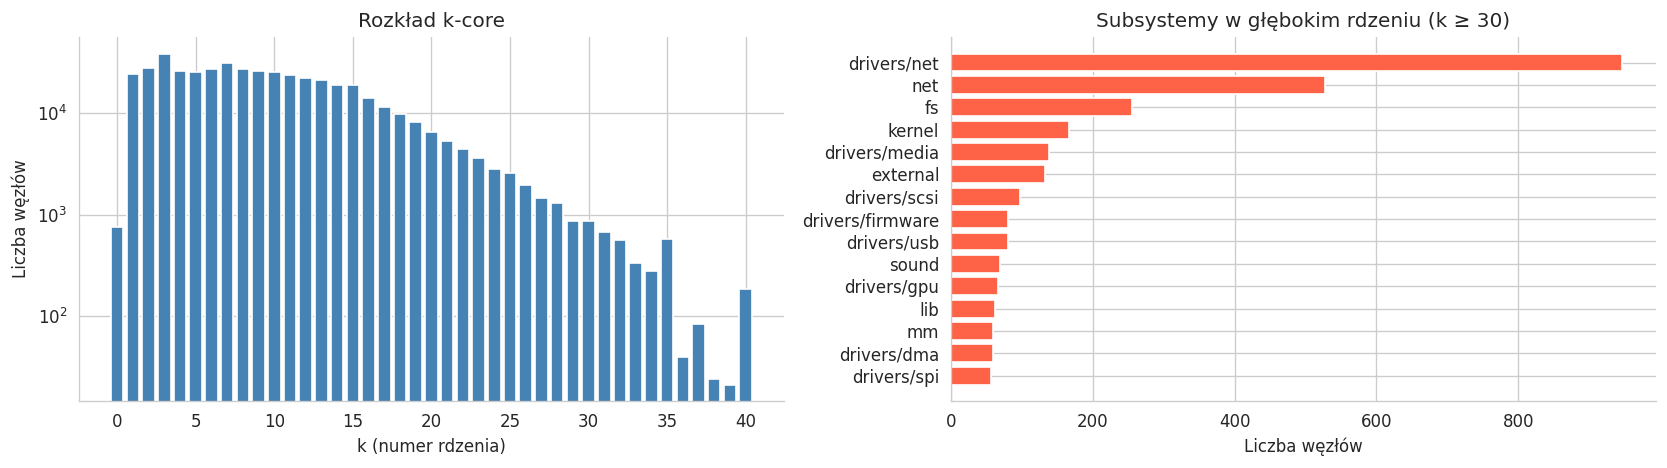


Węzły w głębokim rdzeniu (k ≥ 30):
                   func_name   subsystem  k_core  in_degree     pagerank
    __sanitizer_cov_trace_pc      kernel    40.0   426077.0 5.840043e-02
    nfp_ct_do_nft_merge.isra drivers/net    40.0        0.0 7.098278e-07
               hash_mac4_del         net    40.0        1.0 7.223147e-07
nfp_flower_remove_merge_flow drivers/net    40.0        2.0 8.969032e-07
            hash_ipport4_add         net    40.0        1.0 7.223147e-07
            hash_ipport6_add         net    40.0        1.0 7.223147e-07
            hash_ipport6_del         net    40.0        1.0 7.223147e-07
            hash_ipport4_del         net    40.0        1.0 7.223147e-07
          hash_ipportip4_add         net    40.0        1.0 7.223147e-07
          hash_ipportip6_add         net    40.0        1.0 7.220243e-07
          hash_ipportip6_del         net    40.0        1.0 7.220243e-07
          hash_ipportip4_del         net    40.0        1.0 7.223147e-07
            has

In [ ]:
print("Obliczam k-core (NetworKit CoreDecomposition)...")
core = nk.centrality.CoreDecomposition(G)
core.run()
core_numbers = np.array([core.score(i) for i in range(n_nodes)])
metrics["k_core"] = core_numbers

k_max = int(core_numbers.max())
print(f"Maksymalne k-core: {k_max}")
print(f"Rozmiar maksymalnego k-core: {(core_numbers == k_max).sum():,} węzłów")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
vals, counts = np.unique(core_numbers, return_counts=True)
ax.bar(vals, counts, color="steelblue", width=0.8)
ax.set_xlabel("k (numer rdzenia)")
ax.set_ylabel("Liczba węzłów")
ax.set_title("Rozkład k-core")
ax.set_yscale("log")

deep_threshold = int(k_max * 0.75)
deep_core = metrics[metrics["k_core"] >= deep_threshold]
ax = axes[1]
sys_deep = deep_core["subsystem"].value_counts().head(15).iloc[::-1]
ax.barh(sys_deep.index, sys_deep.values, color="tomato")
ax.set_xlabel("Liczba węzłów")
ax.set_title(f"Subsystemy w głębokim rdzeniu (k ≥ {deep_threshold})")

plt.tight_layout()
plt.savefig(DATA / "kcore.png", bbox_inches="tight")
plt.show()

print(f"\nWęzły w głębokim rdzeniu (k ≥ {deep_threshold}):")
print(
    deep_core[["func_name", "subsystem", "k_core", "in_degree", "pagerank"]]
    .sort_values("k_core", ascending=False)
    .head(20)
    .to_string(index=False)
)

## 7. Porównanie centrality: in-degree vs PageRank vs k-core

Czy różne miary centralności wskazują na te same węzły? Korelacja między nimi powie nam, ile "różnych typów ważności" istnieje w tej sieci.

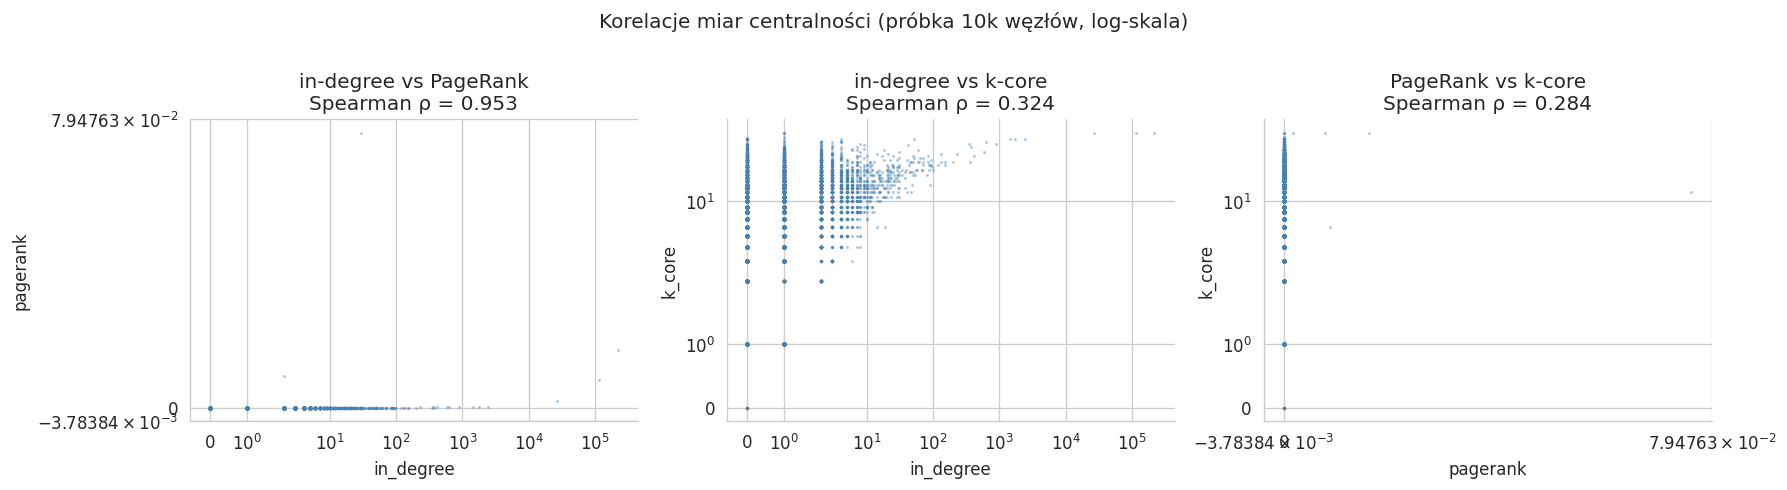

Rangi Spearmana (cały zbiór):
  in-degree vs PageRank: ρ = 0.9532, p = 0.00e+00
  in-degree vs k-core: ρ = 0.3238, p = 0.00e+00
  PageRank vs k-core: ρ = 0.2836, p = 0.00e+00


In [ ]:
from scipy.stats import spearmanr

sample = metrics.sample(10_000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ("in_degree", "pagerank", "in-degree vs PageRank"),
    ("in_degree", "k_core", "in-degree vs k-core"),
    ("pagerank", "k_core", "PageRank vs k-core"),
]

for ax, (x, y, title) in zip(axes, pairs):
    rho, pval = spearmanr(metrics[x], metrics[y])
    ax.scatter(sample[x], sample[y], s=1, alpha=0.3, color="steelblue")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{title}\nSpearman ρ = {rho:.3f}")
    ax.set_xscale("symlog")
    ax.set_yscale("symlog")

plt.suptitle(
    "Korelacje miar centralności (próbka 10k węzłów, log-skala)", fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(DATA / "centrality_correlation.png", bbox_inches="tight")
plt.show()

print("Rangi Spearmana (cały zbiór):")
for x, y, title in pairs:
    rho, pval = spearmanr(metrics[x], metrics[y])
    print(f"  {title}: ρ = {rho:.4f}, p = {pval:.2e}")

## 8. Wnioski i obserwacje

### Rozkład stopni
- In-degree (bez artefaktów KCOV) ma rozkład potęgowy z **γ ≈ 2.06**, out-degree **γ ≈ 2.12**, degree total **γ ≈ 2.01**
- Wszystkie γ ∈ (2, 3) — klasyczny zakres dla sieci **bezskalowych** (scale-free networks)
- CCDF in-degree jest prostą linią w skali log-log ponad 5 rzędami wielkości — silne potwierdzenie power-law
- Out-degree ma wyraźne obcięcie przy k ≈ 100 (funkcje rzadko wywołują więcej niż 100 różnych innych funkcji)

### Huby
- Top in-degree zdominowane przez **artefakty sanitizerów** (KCOV, ASAN, UBSAN) — wstrzykiwane automatycznie przez kompilator do każdej funkcji przy `allmodconfig`
- Pierwsze "prawdziwe" huby: `memset` (43k), `_stack_chk_fail` (99k), `_dev_err` (31k) — niskopoziomowe funkcje libC/kernelowe
- PageRank wyłania inne huby: **`_text`** (PR=0.076) — symbol oznaczający start sekcji kodu, `kasan_report` (0.052), `printk` (0.012)
- Spearman in-degree vs PageRank **ρ = 0.953** — bardzo silna korelacja, obie miary wskazują na ten sam typ "popularności"

### Subsystemy
- Największy subsystem: **`drivers/clk`** (~5600 węzłów)
- Największy przepływ krzyżowy: **`drivers/net` → `kernel`** (281,636 wywołań), **`drivers/net` → `mm`** (223,006)
- `kernel` i `mm` to kolumny docelowe — niemal każdy subsystem do nich dzwoni (widać w heatmapie)
- Samowystarczalność subsystemów jest generalnie niska — kod Linuxa jest silnie sprzężony ponad granicami modułów

### Społeczności (Louvain)
- **NMI = 0.115** — bardzo niskie; algorytm praktycznie nie odgaduje struktury subsystemów
- Oznacza to, że **granice wywołań funkcji nie pokrywają się z granicami katalogów** — Linux jest architektonicznie sprzężony "w poprzek" subsystemów
- Społeczności Louvain to mieszanki wielu subsystemów — brak izolowanych klastrów
- Porównanie: dla sieci społecznościowej (np. CiteSeer z Lab 04) NMI jest znacznie wyższe

### k-core
- Maksymalne k-core: **k = 40**
- Głęboki rdzeń (k ≥ 30) tworzą głównie: **`drivers/net`**, **`net`**, **`fs`** — sieciowanie i system plików, _nie_ `kernel/`
- Niespodziewany wynik: sterowniki sieciowe są najbardziej wzajemnie powiązane w całym grafie
- Spearman in-degree vs k-core **ρ = 0.324** — słaba korelacja: bycie "popularnym" (dużo wywołań) ≠ bycie w głębokim rdzeniu (wzajemne gęste powiązania)
- k-core i PageRank też słabo skorelowane (ρ = 0.284) — trzy miary opisują **różne wymiary ważności** węzłów

### Kluczowy wniosek
Sieć wywołań funkcji Linuxa jest **siecią bezskalową** z kilkoma super-hubami (KCOV/sanitizery) i długim ogonem. Struktura modularności według katalogów źródłowych jest słabo odzwierciedlona w topologii grafu — kod "wylewa się" ponad granicami subsystemów, szczególnie w kierunku `kernel/` i `mm/`. Rdzeń sieci tworzą sterowniki sieciowe, co odpowiada intensywnemu cross-stack calling typowemu dla stosu TCP/IP.